In [15]:
print("WELCOME TO BREAST CANCER REPORT")

WELCOME TO BREAST CANCER REPORT


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    mean_squared_error,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("METABRIC_RNA_Mutation.csv", low_memory=False)

print("Shape of data:", df.shape)
print(df.info())
print(df.describe())

Shape of data: (1904, 693)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Columns: 693 entries, patient_id to siah1_mut
dtypes: float64(498), int64(5), object(190)
memory usage: 10.1+ MB
None
        patient_id  age_at_diagnosis  chemotherapy       cohort  \
count  1904.000000       1904.000000   1904.000000  1904.000000   
mean   3921.982143         61.087054      0.207983     2.643908   
std    2358.478332         12.978711      0.405971     1.228615   
min       0.000000         21.930000      0.000000     1.000000   
25%     896.500000         51.375000      0.000000     1.000000   
50%    4730.500000         61.770000      0.000000     3.000000   
75%    5536.250000         70.592500      0.000000     3.000000   
max    7299.000000         96.290000      1.000000     5.000000   

       neoplasm_histologic_grade  hormone_therapy  \
count                1832.000000      1904.000000   
mean                    2.415939         0.616597   
std               

In [3]:
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr(numeric_only=True)["overall_survival"]
correlation = correlation.drop("overall_survival")
correlation = correlation.sort_values(key=abs, ascending=False)
print("Top correlated features with survival:")
print(correlation.head(10))


Top correlated features with survival:
overall_survival_months    0.384467
age_at_diagnosis          -0.303666
hsd17b11                   0.216095
cdkn2c                     0.197379
jak1                       0.194412
tumor_stage               -0.188790
gsk3b                     -0.186323
spry2                      0.184942
lama2                      0.172530
kmt2c                     -0.171925
Name: overall_survival, dtype: float64


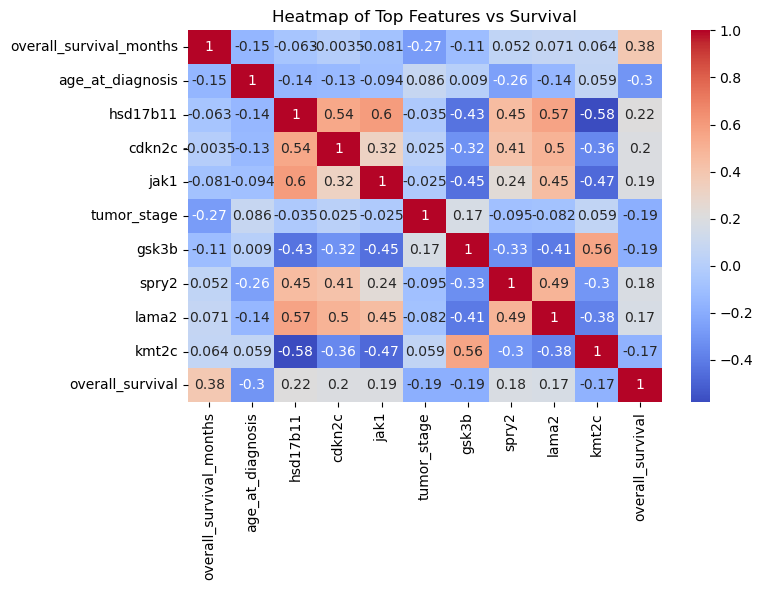

In [5]:
top_features = correlation.head(10).index.tolist()
top_features.append("overall_survival")   # add target column back for the picture

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df[top_features].corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap of Top Features vs Survival")
plt.tight_layout()
plt.savefig("heatmap.png")
plt.show()
plt.close()


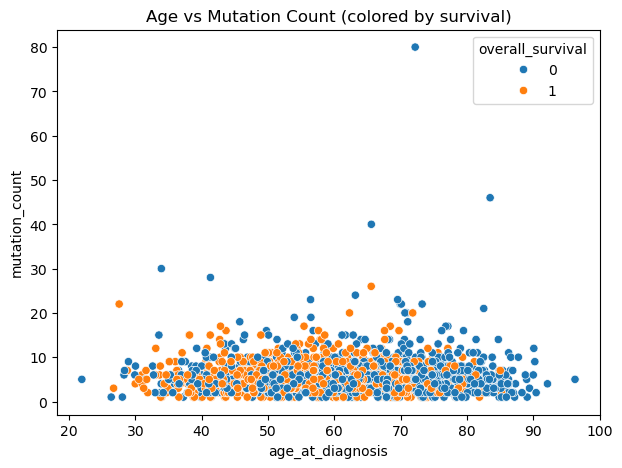

In [6]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="age_at_diagnosis",
    y="mutation_count",
    hue="overall_survival"
)
plt.title("Age vs Mutation Count (colored by survival)")
plt.savefig("scatter_plot.png")
plt.show()
plt.close()


In [19]:

df = df.dropna()
print("Shape after dropna:", df.shape)
le = LabelEncoder()
text_columns = df.select_dtypes(include=["object"]).columns
print("Text columns found:", list(text_columns))
for col in text_columns:
    column_as_text = df[col].astype(str)  
    df[col] = le.fit_transform(column_as_text)   
X = df.drop("overall_survival", axis=1)
y = df["overall_survival"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 9: Balance the training data using SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

Shape after dropna: (1093, 690)
Text columns found: []


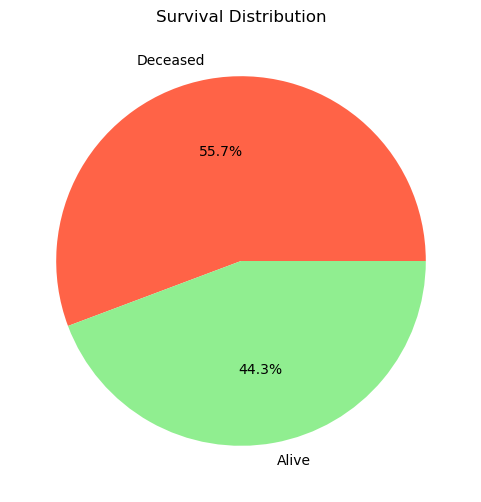

In [9]:
plt.figure(figsize=(6, 6))
y.value_counts().plot.pie(
    labels=["Deceased", "Alive"],
    autopct="%1.1f%%",
    colors=["tomato", "lightgreen"]
)
plt.title("Survival Distribution")
plt.ylabel("")
plt.savefig("survival_pie_chart.png")
plt.close()

In [10]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_bal, y_train_bal)
y_pred_lr = model_lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)

print("Logistic Regression Results")
print("Accuracy:", acc_lr)
print("Recall:", recall_lr)
print("F1 Score:", f1_lr)
print("MSE:", mse_lr)
print(classification_report(y_test, y_pred_lr, target_names=["Deceased", "Alive"]))

Logistic Regression Results
Accuracy: 0.593607305936073
Recall: 0.5360824742268041
F1 Score: 0.538860103626943
MSE: 0.4063926940639269
              precision    recall  f1-score   support

    Deceased       0.63      0.64      0.64       122
       Alive       0.54      0.54      0.54        97

    accuracy                           0.59       219
   macro avg       0.59      0.59      0.59       219
weighted avg       0.59      0.59      0.59       219



In [11]:
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train_bal, y_train_bal)
y_pred_dt = model_dt.predict(X_test_scaled)

acc_dt = accuracy_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)

print("Decision Tree Results")
print("Accuracy:", acc_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)
print("MSE:", mse_dt)
print(classification_report(y_test, y_pred_dt, target_names=["Deceased", "Alive"]))

Decision Tree Results
Accuracy: 0.684931506849315
Recall: 0.6082474226804123
F1 Score: 0.6310160427807486
MSE: 0.3150684931506849
              precision    recall  f1-score   support

    Deceased       0.71      0.75      0.73       122
       Alive       0.66      0.61      0.63        97

    accuracy                           0.68       219
   macro avg       0.68      0.68      0.68       219
weighted avg       0.68      0.68      0.68       219



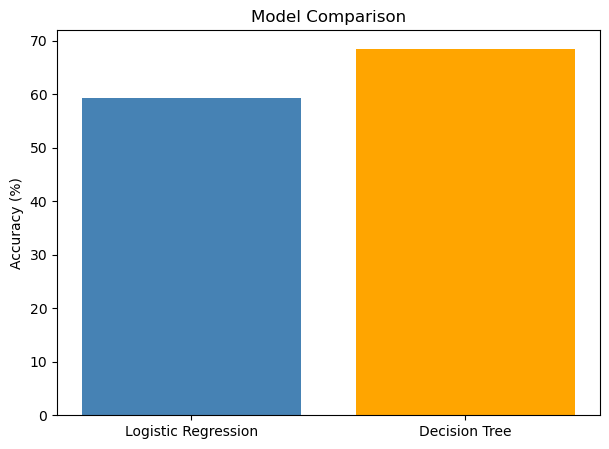

In [12]:
models = ["Logistic Regression", "Decision Tree"]
accuracies = [acc_lr * 100, acc_dt * 100]

plt.figure(figsize=(7, 5))
plt.bar(models, accuracies, color=["steelblue", "orange"])
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.savefig("model_comparison.png")
plt.show()
plt.close()


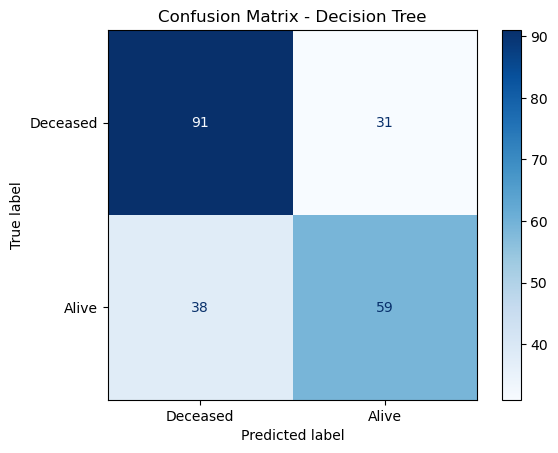

In [13]:
if acc_lr > acc_dt:
    best_name = "Logistic Regression"
    best_preds = y_pred_lr
else:
    best_name = "Decision Tree"
    best_preds = y_pred_dt

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Deceased", "Alive"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - " + best_name)
plt.savefig("confusion_matrix.png")
plt.show()
plt.close()

